In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import tensorflow as tf
from tensorflow import keras


C:\Users\jaadt\AppData\Local\Temp\ipykernel_2200\2897261863.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


1. Using your fire dataset develop a method of labeling which pixels are associated with the fire (using the segmentation data set)
2. Develop a method that label which pixels in the Fire vs No Fire dataset have fire in them.


In [2]:
BATCH_SIZE = 128

image_train = tf.keras.utils.image_dataset_from_directory(
    "Images/",
    validation_split=0.2,
    subset="training",
    seed=42,
    batch_size=BATCH_SIZE,
    label_mode=None
)

image_test = tf.keras.utils.image_dataset_from_directory(
    "Images/",
    validation_split=0.2,
    subset="validation",
    seed=42,
    batch_size=BATCH_SIZE,
    label_mode=None
)

mask_train = tf.keras.utils.image_dataset_from_directory(
    "Masks/",
    validation_split=0.2,
    subset="training",
    seed=42,
    batch_size=BATCH_SIZE,
    label_mode=None,
    color_mode="grayscale"
)

mask_test = tf.keras.utils.image_dataset_from_directory(
    "Masks/",
    validation_split=0.2,
    subset="validation",
    seed=42,
    batch_size=BATCH_SIZE,
    label_mode=None,
    color_mode="grayscale"
)

train_dataset = tf.data.Dataset.zip((image_train, mask_train))
test_dataset = tf.data.Dataset.zip((image_test, mask_test))

Found 2003 files.
Using 1603 files for training.
Found 2003 files.
Using 400 files for validation.
Found 2003 files.
Using 1603 files for training.
Found 2003 files.
Using 400 files for validation.


In [3]:
def normalize(input_image, input_mask):
    input_image = tf.cast(input_image, tf.float32) / 255.0
    input_mask = input_mask 
    return input_image, input_mask

def load_image(image, mask):
    image = tf.image.resize(image, (128, 128))  
    mask = tf.image.resize(
        mask,
        (128, 128),
        method=tf.image.ResizeMethod.NEAREST_NEIGHBOR
    )
    image, mask = normalize(image, mask)
    return image, mask

In [4]:
train_dataset = train_dataset.map(
    lambda x, y: load_image(x, y),
    num_parallel_calls=tf.data.AUTOTUNE
)

test_dataset = test_dataset.map(
    lambda x, y: load_image(x, y),
    num_parallel_calls=tf.data.AUTOTUNE
)

In [5]:
class Augment(tf.keras.layers.Layer):

    def __init__(self, seed=42):
        super().__init__()

        self.augment_inputs = tf.keras.layers.RandomFlip(
            mode="horizontal",
            seed=seed
        )

        self.augment_labels = tf.keras.layers.RandomFlip(
            mode="horizontal",
            seed=seed
        )

    def call(self, inputs, labels):
        inputs = self.augment_inputs(inputs)
        labels = self.augment_labels(labels)
        return inputs, labels
    
    

In [6]:
BUFFER_SIZE = 10

train_batches = (
    train_dataset
    .cache()
    .shuffle(BUFFER_SIZE)
    .map(Augment())
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)

test_batches = (
    test_dataset
    .cache()
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)


def display(display_list):

    plt.figure(figsize=(15,15))

    title = ['Input Image','True Mask','Predicted Mask']

    for i in range(len(display_list)):

        plt.subplot(1,len(display_list),i+1)
        plt.title(title[i])

        plt.imshow(tf.keras.utils.array_to_img(display_list[i]))

        plt.axis('off')

    plt.show()

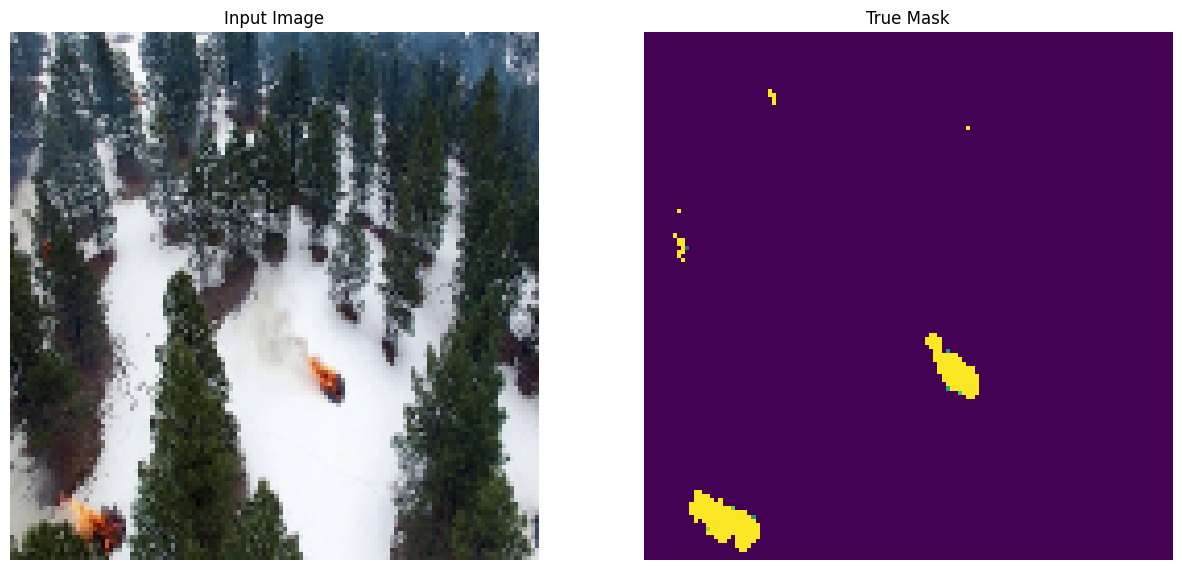

In [7]:
for images, masks in train_batches.take(1):

    sample_image = images[0]
    sample_mask = masks[0]

    display([sample_image, sample_mask])

In [8]:
model = keras.models.Sequential([
    keras.layers.Conv2D(16,3,activation='relu',padding='same'),
    keras.layers.Conv2D(16,3,activation='relu',padding='same'),
    keras.layers.MaxPooling2D(),
    keras.layers.Dropout(0.1),
    keras.layers.Conv2D(32,3,activation='relu',padding='same'),

    keras.layers.Conv2D(32,3,activation='relu',padding='same'),
    keras.layers.Dropout(0.1),
    keras.layers.UpSampling2D(),
    keras.layers.Conv2D(64,3,activation='relu',padding='same'),
    keras.layers.Conv2D(64,3,activation='relu',padding='same'),
    keras.layers.Dropout(0.2),
    keras.layers.Conv2D(1, (1, 1), activation='sigmoid')])

def dice_coef(y_true, y_pred, smooth=100):
    y_true_f = tf.cast(tf.keras.backend.flatten(y_true), tf.float32)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), 
              loss=dice_loss, 
              metrics=['accuracy'])


In [9]:
def create_mask(pred_mask):
  pred_mask = tf.math.argmax(pred_mask, axis=-1)
  pred_mask = pred_mask[..., tf.newaxis]
  return pred_mask[0]


In [10]:
def show_predictions(dataset=None, num=1):
  for image, mask in dataset.take(num):
        pred_mask = model.predict(image)
        
        # KEY FIX: Create a binary label (1 for fire, 0 for background)
        # Use 0.1 for now since your max is 0.23, move to 0.5 after more training
        label_mask = (pred_mask[0] > 0.2).astype(np.uint8) 

        plt.figure(figsize=(12, 4))
        plt.subplot(1, 3, 1); plt.title("Input Image"); plt.imshow(image[0])
        plt.subplot(1, 3, 2); plt.title("True Mask"); plt.imshow(mask[0], cmap='gray')
        plt.subplot(1, 3, 3); plt.title("Labeled Output"); plt.imshow(label_mask, cmap='gray')
        plt.show()

In [11]:
EPOCHS = 10

history = model.fit(
    train_batches,
    epochs=EPOCHS,
    validation_data=test_batches
)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.1690 - loss: 0.9882 - val_accuracy: 0.0058 - val_loss: 0.9882
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.0066 - loss: 0.9880 - val_accuracy: 0.0058 - val_loss: 0.9879
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.0062 - loss: 0.9876 - val_accuracy: 0.0059 - val_loss: 0.9874
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step - accuracy: 0.0086 - loss: 0.9871 - val_accuracy: 0.0294 - val_loss: 0.9868
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step - accuracy: 0.1730 - loss: 0.9860 - val_accuracy: 0.6346 - val_loss: 0.9847
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.7439 - loss: 0.9826 - val_accuracy: 0.9482 - val_loss: 0.9784
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step - accuracy: 0.9526 - loss: 0.9703 - val_accuracy: 0.9881 - val_loss: 0.9491
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.9884 - loss: 0.9127 - val_accuracy: 0.9956 - val_loss:

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


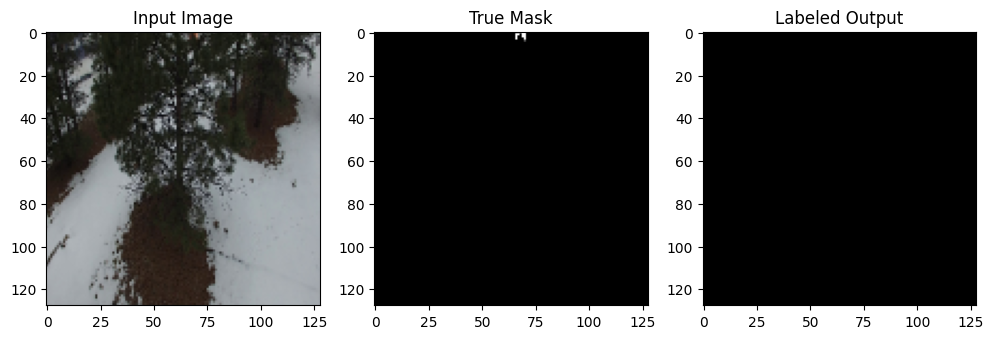

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


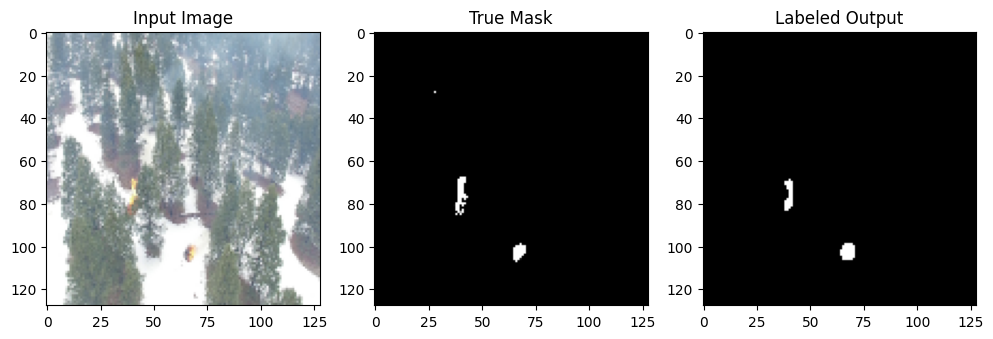

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


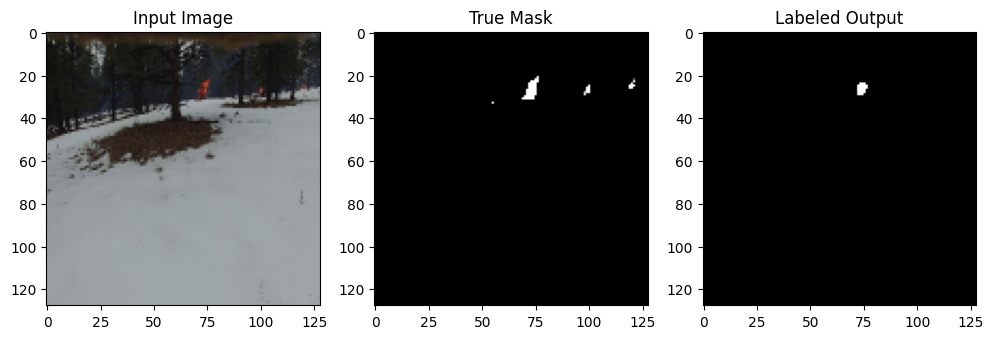

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step


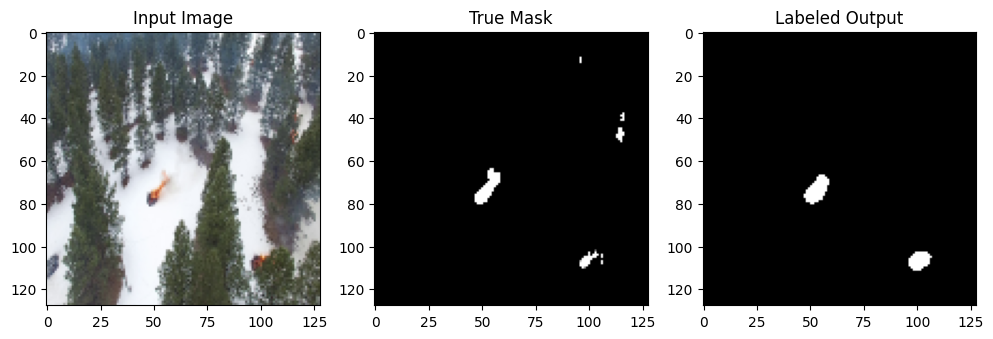

In [12]:
show_predictions(test_batches, num=7)

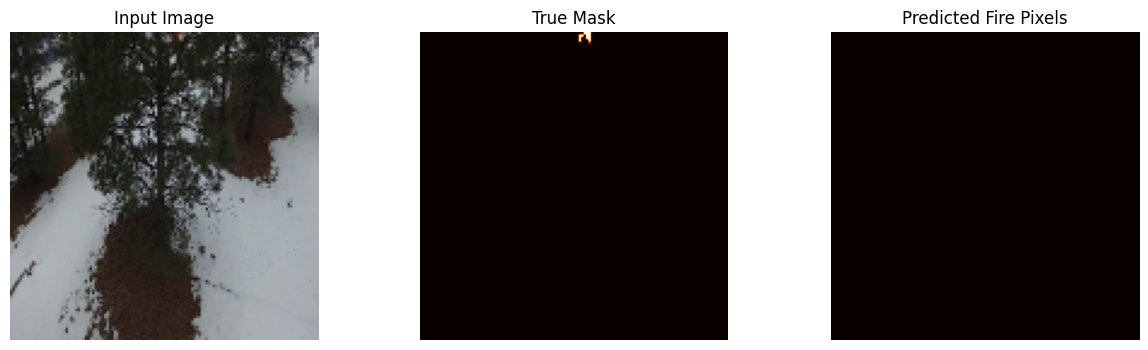

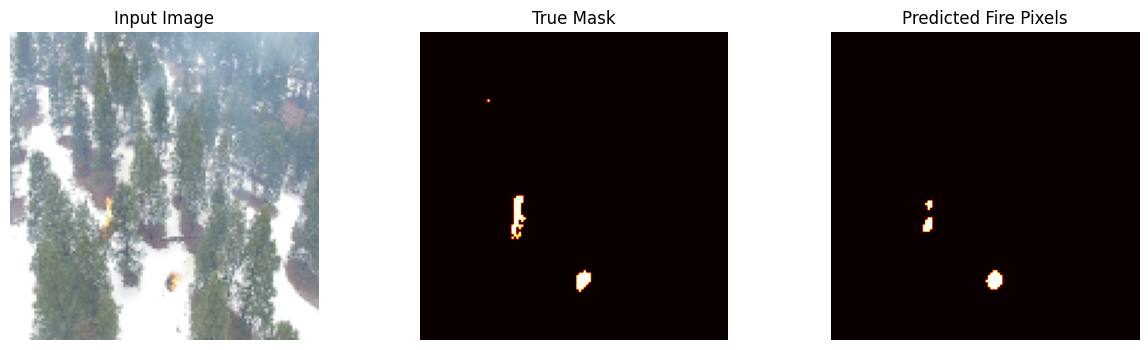

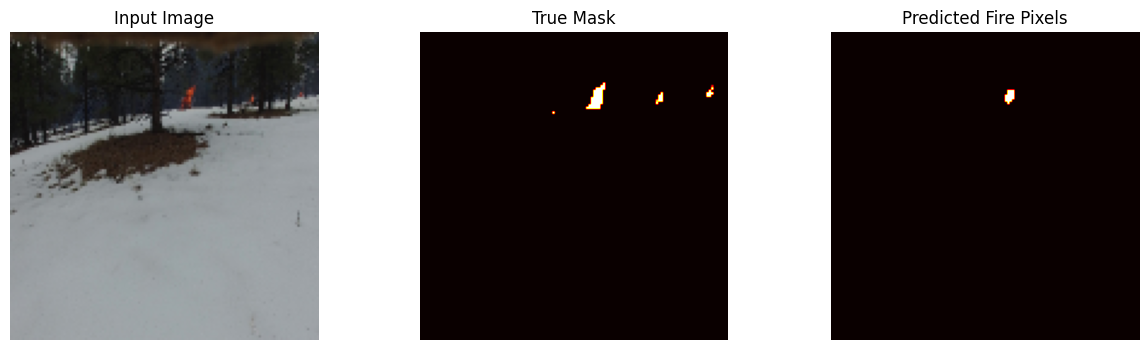

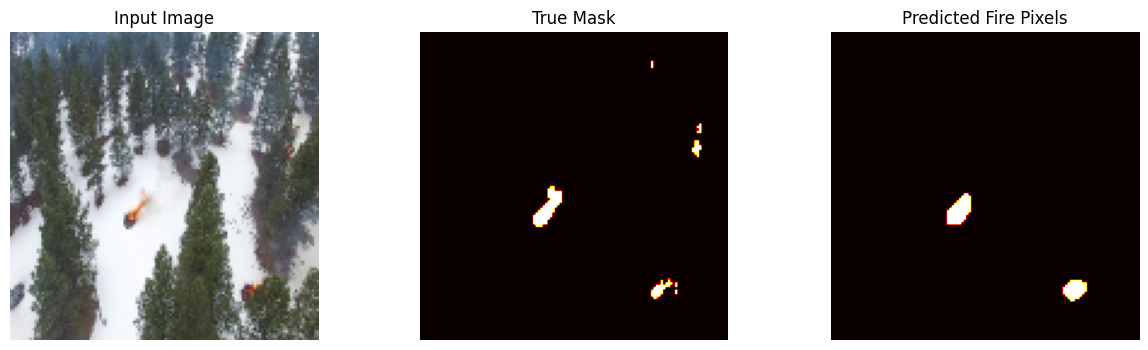

In [13]:
def predict_fire_pixels(dataset, num=5):
    for image, mask in dataset.take(num):
        # model.predict returns probabilities between 0 and 1
        predictions = model.predict(image, verbose=0)
        
        # KEY CHANGE: Instead of create_mask (argmax), use a threshold
        # This creates a mask where pixels > 0.5 are 1 (Fire) and others are 0
        fire_pixels = (predictions[0] > 0.5).astype(np.float32)

        plt.figure(figsize=(15, 4))
        plt.subplot(1, 3, 1)
        plt.title("Input Image")
        plt.imshow(image[0]) # No need for array_to_img if already normalized
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.title("True Mask")
        plt.imshow(mask[0], cmap='hot')
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.title("Predicted Fire Pixels")
        plt.imshow(fire_pixels, cmap='hot')
        plt.axis('off')
        plt.show()

predict_fire_pixels(test_batches)

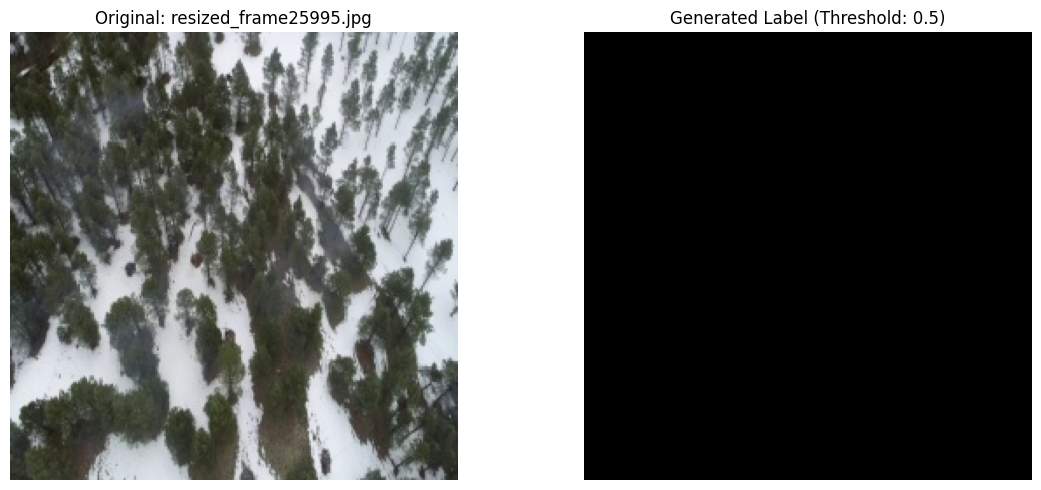

File: resized_frame25995.jpg | Max Probability: 0.2324


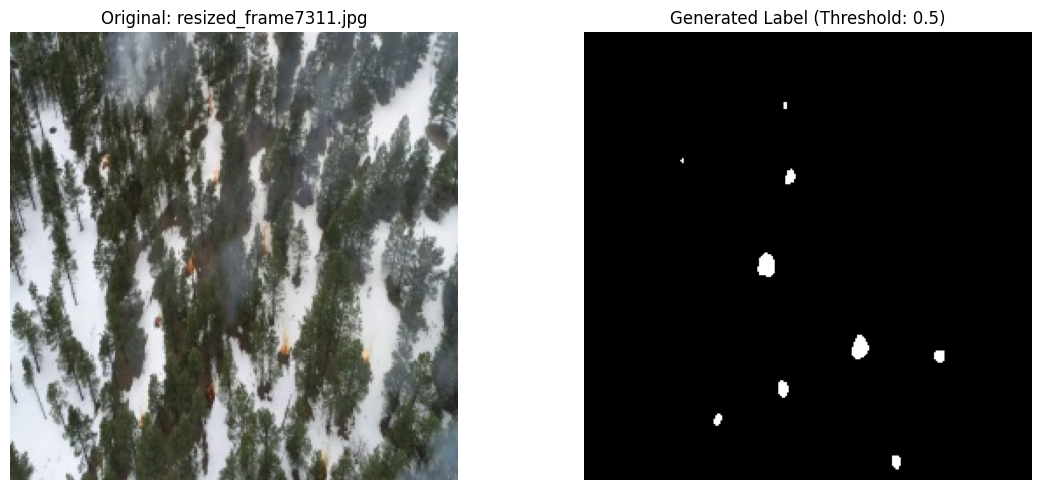

File: resized_frame7311.jpg | Max Probability: 1.0000


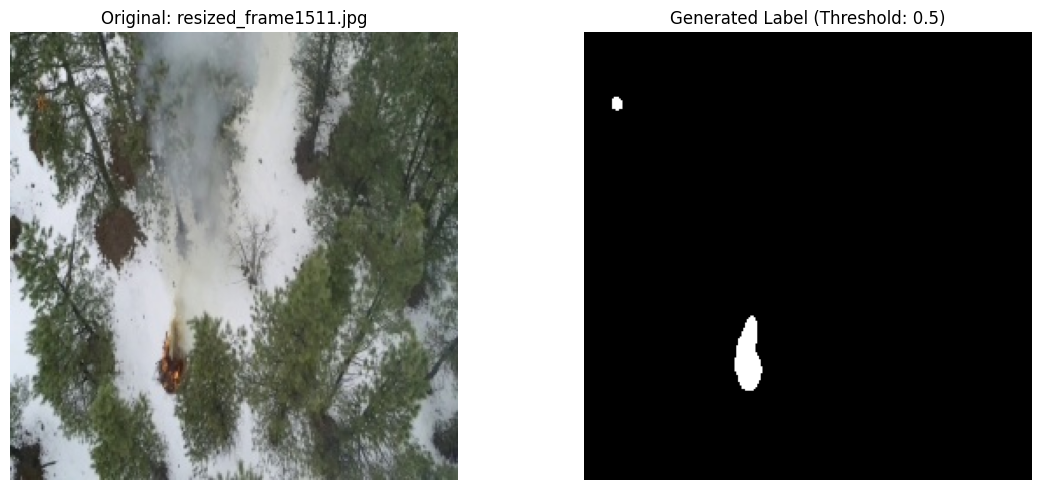

File: resized_frame1511.jpg | Max Probability: 1.0000


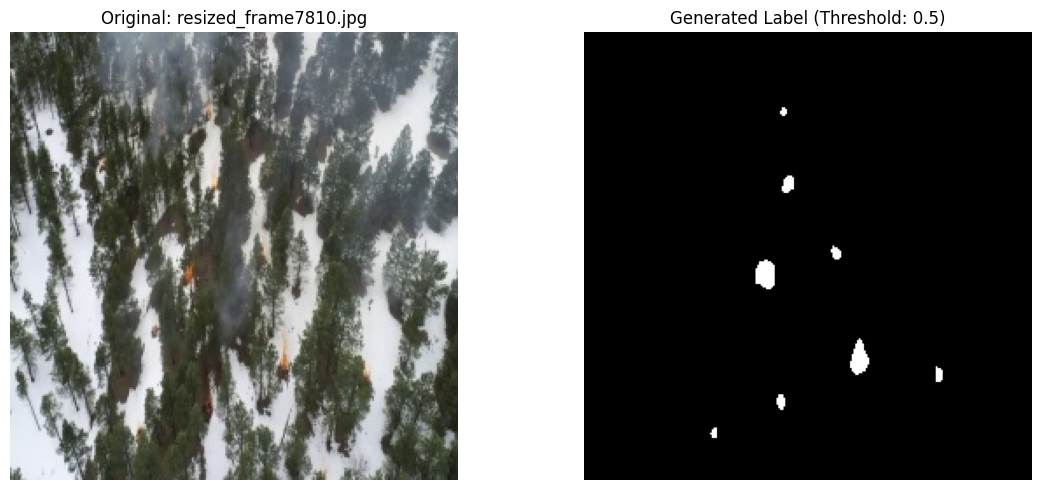

File: resized_frame7810.jpg | Max Probability: 1.0000


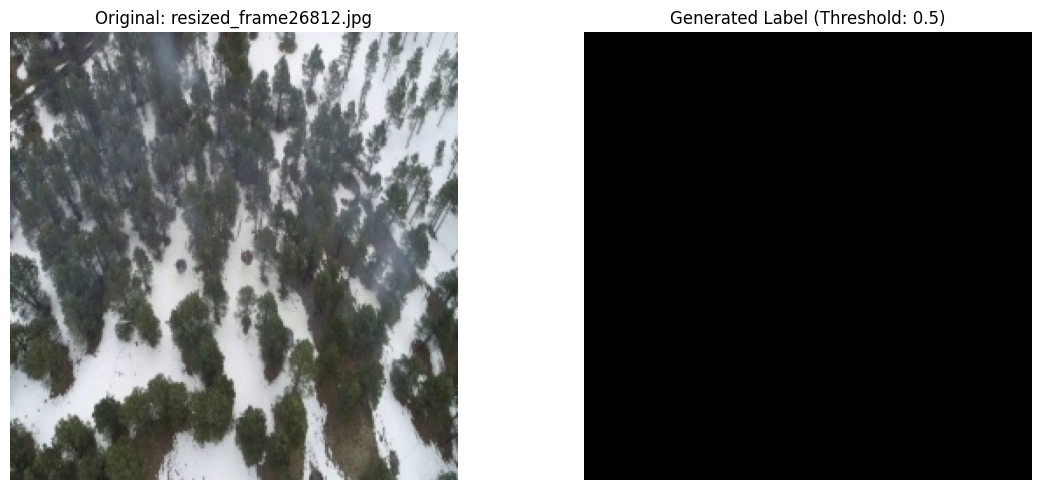

File: resized_frame26812.jpg | Max Probability: 0.2016


In [14]:
import os
import random
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

def plot_random_comparisons(folder_path, model, n=3, threshold=0.5):
    # 1. Get list of all images in the folder
    # Filter for common image extensions
    valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp')
    all_files = [f for f in os.listdir(folder_path) if f.lower().endswith(valid_extensions)]
    
    if len(all_files) < n:
        print(f"Warning: Only found {len(all_files)} images in folder. Plotting all of them.")
        n = len(all_files)
    
    # 2. Pick n random images
    random_files = random.sample(all_files, n)
    
    # 3. Plotting Loop
    for filename in random_files:
        img_path = os.path.join(folder_path, filename)
        
        # Preprocess
        img = tf.keras.utils.load_img(img_path, target_size=(256, 256))
        img_arr = tf.keras.utils.img_to_array(img) / 255.0
        input_batch = np.expand_dims(img_arr, axis=0)
        
        # Predict
        predictions = model.predict(input_batch, verbose=0)
        
        # Method: Thresholding to create binary labels (Task 2)
        labeled_mask = (predictions[0] > threshold).astype(np.uint8)
        
        # Visualization
        plt.figure(figsize=(12, 5))
        
        # Left: Original
        plt.subplot(1, 2, 1)
        plt.title(f"Original: {filename}")
        plt.imshow(img_arr)
        plt.axis('off')
        
        # Right: Labeled Output
        plt.subplot(1, 2, 2)
        plt.title(f"Generated Label (Threshold: {threshold})")
        plt.imshow(labeled_mask.squeeze(), cmap='gray')
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()
        
        # Debugging: Tells you how sure the model was about the "fire-est" pixel
        print(f"File: {filename} | Max Probability: {np.max(predictions):.4f}")

# --- HOW TO RUN IT ---
# Point this to your folder containing the images
fire_folder = r"Training_Bi\Fire" 

# Pick 5 random images and compare
plot_random_comparisons(fire_folder, model, n=5, threshold=0.5)

In [15]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Scalable Custom Segmentation Model
def build_seg_model_scaled(model_size='medium'):
    # Define scaling factors for filters
    scales = {
        'very_small': 8,   
        'small':      16,  
        'medium':     32,  
        'large':      64, 
    }
    base_filters = scales[model_size]
    
    inputs  = tf.keras.layers.Input(shape=(128, 128, 3))

    # Encoder
    x = layers.Conv2D(base_filters, 3, activation='relu', padding='same')(inputs)
    x = layers.Conv2D(base_filters, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.2)(x)

    # Bottleneck
    x = layers.Conv2D(base_filters * 2, 3, activation='relu', padding='same')(x)
    x = layers.Conv2D(base_filters * 2, 3, activation='relu', padding='same')(x)

    # Decoder
    x = layers.UpSampling2D()(x)
    x = layers.Conv2D(base_filters, 3, activation='relu', padding='same')(x)
    
    # Output layer for binary segmentation mask
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(x) 

    model = keras.models.Model(inputs, outputs, name=f"Custom_{model_size}")
    
    model.compile(
        optimizer=keras.optimizers.Adam(1e-4),
        loss=dice_loss,
        # BinaryIoU is the perfect metric for 2-class (fire/not-fire) segmentation
        metrics=['accuracy']
    )
    return model

# 2. Standard U-Net Model (For Comparison)
def build_unet():
    inputs = tf.keras.Input(shape=(128, 128, 3))

    # Downsampling
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
    p1 = layers.MaxPooling2D()(c1)
    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(p1)
    p2 = layers.MaxPooling2D()(c2)

    # Bottleneck
    c3 = layers.Conv2D(64, 3, activation='relu', padding='same')(p2)
 
    # Upsampling
    u4 = layers.UpSampling2D()(c3)
    u4 = layers.concatenate([u4, c2])
    c4 = layers.Conv2D(32, 3, activation='relu', padding='same')(u4)
    
    u5 = layers.UpSampling2D()(c4)
    u5 = layers.concatenate([u5, c1])
    c5 = layers.Conv2D(16, 3, activation='relu', padding='same')(u5)

    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c5)
    
    model = keras.models.Model(inputs, outputs, name="U-Net")
    model.compile(
        optimizer=keras.optimizers.Adam(1e-4),
        loss=dice_loss,
        metrics=['accuracy']
    )
    return model

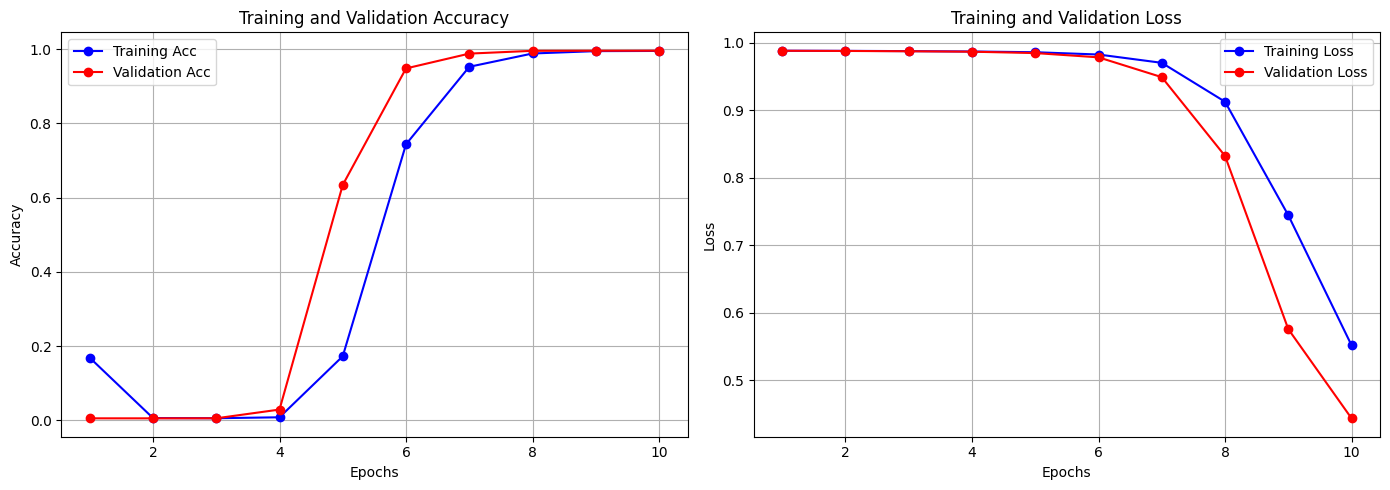

In [17]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    acc = history['accuracy']
    val_acc = history['val_accuracy']
    loss = history['loss']
    val_loss = history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Training Acc')
    plt.plot(epochs, val_acc, 'ro-', label='Validation Acc')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Instead of the loop
plot_training_history(history.history)


--- Training Model: small ---
Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 824ms/step - accuracy: 0.0098 - loss: 0.9881 - val_accuracy: 0.0058 - val_loss: 0.9881
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 804ms/step - accuracy: 0.0058 - loss: 0.9879 - val_accuracy: 0.0058 - val_loss: 0.9879
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 799ms/step - accuracy: 0.0058 - loss: 0.9877 - val_accuracy: 0.0058 - val_loss: 0.9876
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 800ms/step - accuracy: 0.0058 - loss: 0.9874 - val_accuracy: 0.0058 - val_loss: 0.9874
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 802ms/step - accuracy: 0.0058 - loss: 0.9872 - val_accuracy: 0.0060 - val_loss: 0.9872
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 797ms/step - accuracy: 0.0069 - loss: 0.9870 - val_accuracy: 0.0104 - val_loss: 0.9869
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 799ms/step - accuracy: 0.0240 - loss: 0.9867 - val_accuracy: 0.0653 - val_loss: 0.9863
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 794ms/step - accuracy: 0

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


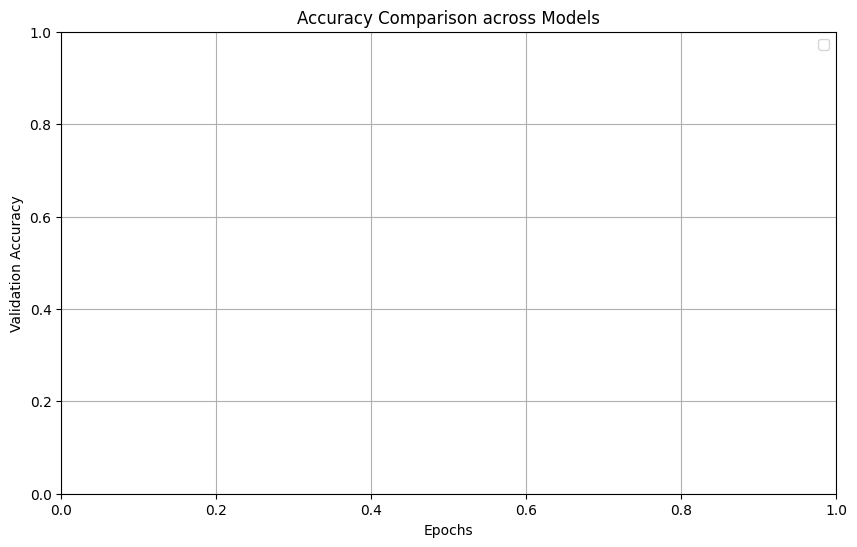

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

model_configs = [
    ('small',  build_seg_model_scaled(model_size='small')),
    ('medium', build_seg_model_scaled(model_size='medium')),
    ('unet',   build_unet())
]

histories      = {}
trained_models = {}

for name, model in model_configs:
    print(f"\n--- Training Model: {name} ---")
    history = model.fit(
        train_batches,          # ← use train_batches (or train_dataset — be consistent)
        epochs=20,
        validation_data=test_batches,   # ← same
        verbose=1
    )
    histories[name]      = history.history   # ✅ save history
    trained_models[name] = model             # ✅ save model

# Plot accuracy comparison
plt.figure(figsize=(10, 6))
for name, hist in histories.items():
    plt.plot(hist['val_accuracy'], label=f'{name} Val Accuracy')

plt.title('Accuracy Comparison across Models')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

Prediction Range: Min=0.0000, Max=0.1786


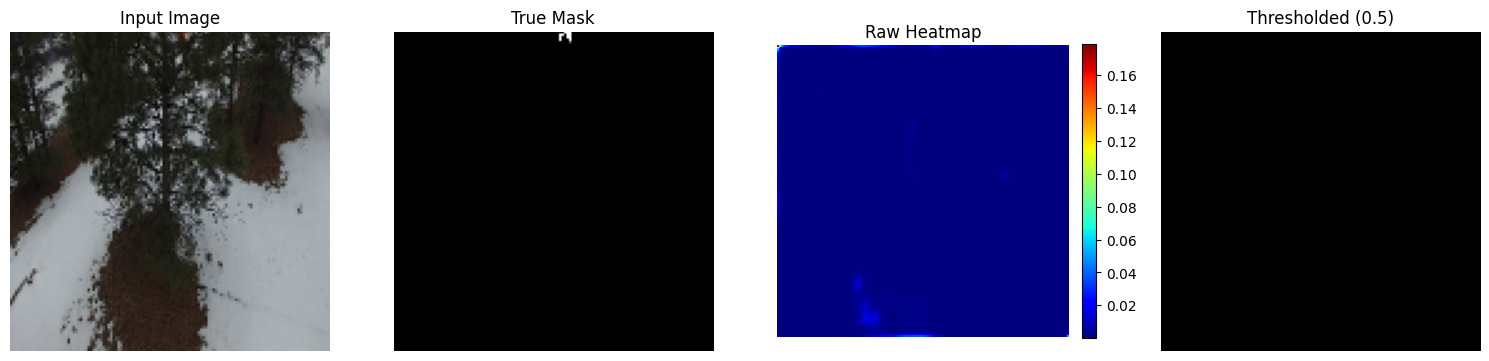

Prediction Range: Min=0.0000, Max=0.9956


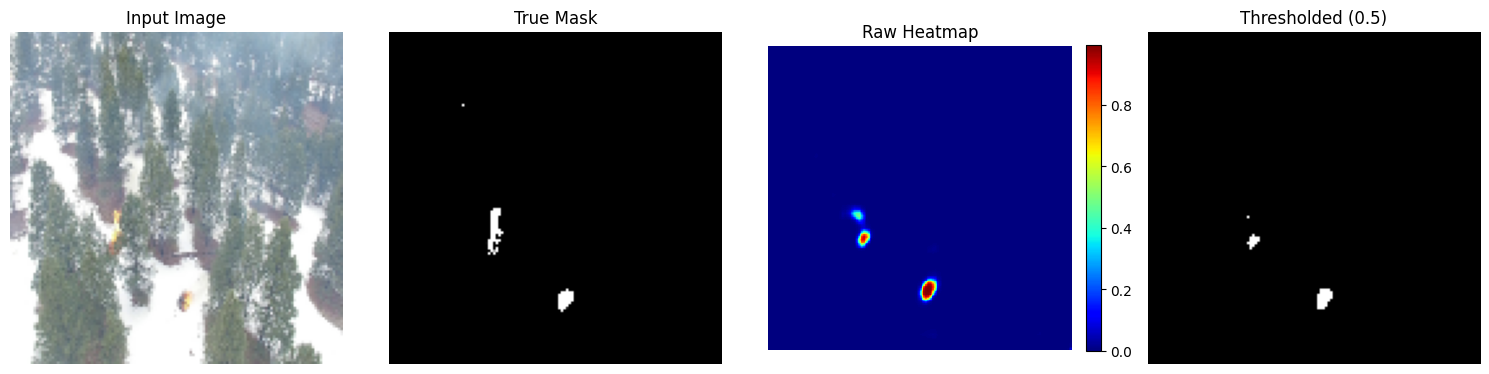

Prediction Range: Min=0.0000, Max=0.9960


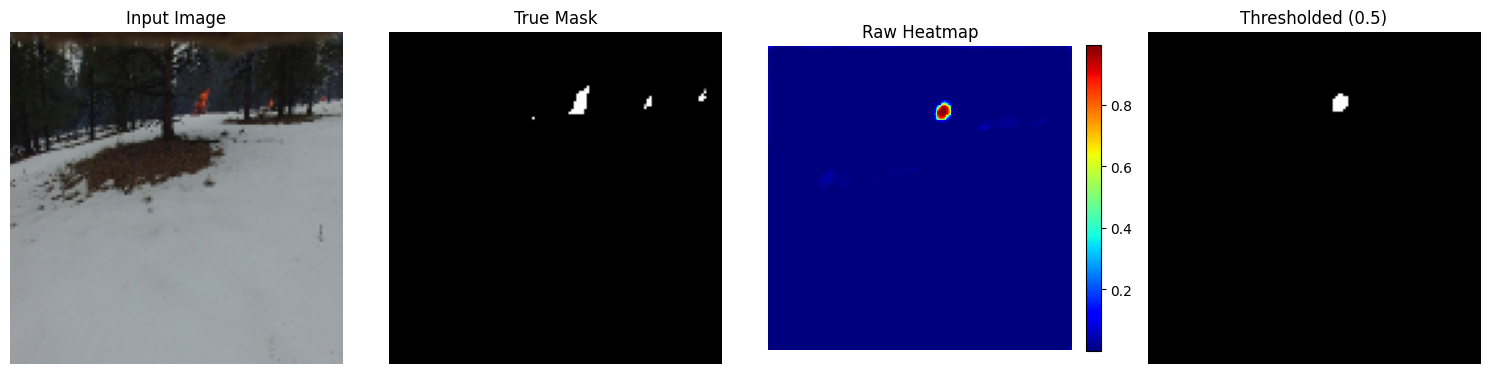

In [19]:
def visualize_predictions(dataset, model, num=3):
    for images, masks in dataset.take(num):
        image = images[0]
        mask = masks[0]
        
        # 1. Direct call to avoid retracing warnings
        pred_raw = model(image[tf.newaxis, ...], training=False)
        
        # 2. Get the raw probability map (0.0 to 1.0)
        pred_array = pred_raw[0].numpy().squeeze()
        
        # DEBUG: This will print in your console so we can see if the model is "alive"
        print(f"Prediction Range: Min={pred_array.min():.4f}, Max={pred_array.max():.4f}")

        # 3. Create the Binary Mask
        binary_pred = (pred_array > 0.5).astype(np.float32)

        plt.figure(figsize=(15, 5))
        
        # Input Image
        plt.subplot(1, 4, 1)
        plt.title("Input Image")
        plt.imshow(image)
        plt.axis('off')

        # True Mask
        plt.subplot(1, 4, 2)
        plt.title("True Mask")
        plt.imshow(np.squeeze(mask), cmap='gray')
        plt.axis('off')

        # Raw Prediction (The Heatmap - helps us see if model is learning anything)
        plt.subplot(1, 4, 3)
        plt.title("Raw Heatmap")
        plt.imshow(pred_array, cmap='jet') # 'jet' makes small differences visible
        plt.colorbar(fraction=0.046, pad=0.04)
        plt.axis('off')

        # Final Binary Mask
        plt.subplot(1, 4, 4)
        plt.title("Thresholded (0.5)")
        plt.imshow(binary_pred, cmap='gray', vmin=0, vmax=1)
        plt.axis('off')

        plt.tight_layout()
        plt.show()

# Run it
visualize_predictions(test_batches, model, num=3)

In [25]:

def compare_predictions_visually_fixed(dataset, models_dict, threshold=0.5):
    """
    Shows: Input | Ground Truth | [Raw Heatmap + Binary Mask] per model.
    Uses dynamic threshold + magma colormap so near-zero predictions are visible.
    """
    for images, masks in dataset.take(1):
        sample_img  = images[0].numpy()
        sample_mask = masks[0].numpy()

        # Normalise image for display (it's already 0-1 from your pipeline)
        display_img = sample_img

        num_models  = len(models_dict)
        # 2 panels per model (heatmap + binary) + input + GT = 2*n + 2 columns
        ncols = 2 * num_models + 2
        fig, axes = plt.subplots(1, ncols, figsize=(4 * ncols, 4))

        # Input
        axes[0].imshow(display_img)
        axes[0].set_title("Input Image", fontsize=10)
        axes[0].axis('off')

        # Ground Truth
        #axes[1].imshow(np.squeeze(sample_mask / 255.0), cmap='gray', vmin=0, vmax=1)
        axes[1].imshow(np.squeeze(sample_mask), cmap='gray', vmin=0, vmax=1)
        axes[1].set_title("Ground Truth", fontsize=10)
        axes[1].axis('off')

        for i, (name, mdl) in enumerate(models_dict.items()):
            input_tensor = sample_img[np.newaxis, ...]        # (1, 128, 128, 3)
            pred_raw     = mdl(input_tensor, training=False)  # (1, 128, 128, 1)
            pred_prob    = pred_raw[0].numpy().squeeze()      # (128, 128) float

            print(f"{name} → min={pred_prob.min():.4f}  max={pred_prob.max():.4f}")

            # --- Heatmap (magma): shows ANY signal even if max is 0.01 ---
            ax_heat = axes[2 + i * 2]
            im = ax_heat.imshow(pred_prob, cmap='magma', vmin=0, vmax=max(pred_prob.max(), 0.01))
            plt.colorbar(im, ax=ax_heat, fraction=0.046, pad=0.04)
            ax_heat.set_title(f"{name}\nHeatmap (max={pred_prob.max():.3f})", fontsize=9)
            ax_heat.axis('off')

            # --- Binary mask with DYNAMIC threshold ---
            # If model never exceeds 0.5, drop threshold to 80% of its max
            dyn_thresh  = 0.5 if pred_prob.max() > 0.5 else pred_prob.max() * 0.8
            binary_mask = (pred_prob > dyn_thresh).astype(np.float32)
            ax_bin = axes[3 + i * 2]
            ax_bin.imshow(binary_mask, cmap='gray', vmin=0, vmax=1)
            ax_bin.set_title(f"{name}\nBinary (t={dyn_thresh:.2f})", fontsize=9)
            ax_bin.axis('off')

        plt.suptitle("Model Comparison — Heatmap + Binary Mask", y=1.02, fontsize=12)
        plt.tight_layout()
        plt.show()


# ── 3. Run it ────────────────────────────────────────────────────────────────
# You must map the names to the actual model objects stored in trained_models
models_dict = {
    "small":  trained_models['small'],
    "medium": trained_models['medium'],
    "unet":   trained_models['unet'],
}

# Now call the visual comparison function
compare_predictions_visually_fixed(test_batches, models_dict)

KeyError: 'small'